In [ ]:
import os
os.makedirs("data", exist_ok=True)

csv_noi_dung = """dien_tich,so_phong,tuoi_nha,gia
35.5,1,18,3.0
37.6,2,7,3.87
49.4,2,20,4.25
49.0,2,16,4.6
49.9,1,12,3.99
40.5,1,14,3.51
44.0,3,12,3.03
45.6,2,8,4.19
46.8,2,11,3.35
47.9,1,19,4.18
50.4,1,1,4.0
51.5,2,0,4.71
51.7,4,18,4.42
52.4,1,9,3.83
61.3,2,20,4.56
55.0,4,0,5.32
56.7,4,23,4.69
57.7,1,3,4.75
58.2,1,10,4.76
59.3,3,25,4.51
59.6,1,2,5.39
63.5,2,17,5.02
64.2,2,18,5.24
66.6,4,11,5.33
68.0,1,2,5.44
69.2,3,13,5.3
69.9,3,11,6.26
71.9,1,22,5.71
74.1,4,17,6.48
74.2,4,8,7.17
76.0,2,1,6.11
77.6,4,15,6.32
78.0,3,7,6.3
79.7,4,17,6.58
82.5,4,22,6.62
84.9,3,9,6.91
85.5,2,23,6.39
87.1,1,13,6.77
88.7,3,13,7.85
89.5,1,19,6.94
91.3,4,20,7.09
91.4,4,23,7.55
92.6,1,25,7.85
94.9,3,3,7.35
91.3,1,10,7.83
99.4,1,24,7.68
100.9,2,7,7.62
101.1,4,0,8.68
101.2,4,14,8.29
104.0,3,19,8.44
106.5,3,19,8.35
107.6,3,21,8.84
107.9,1,16,8.46
110.2,2,3,8.96
110.3,4,22,8.54
113.2,2,10,8.75
113.3,1,22,9.48
116.1,1,21,9.06
117.5,3,25,9.51
115.9,1,0,9.01
"""

with open("data/gia_nha.csv", "w", encoding="utf-8") as f:
    f.write(csv_noi_dung)

print("Da tao data/gia_nha.csv")

Da tao data/gia_nha.csv


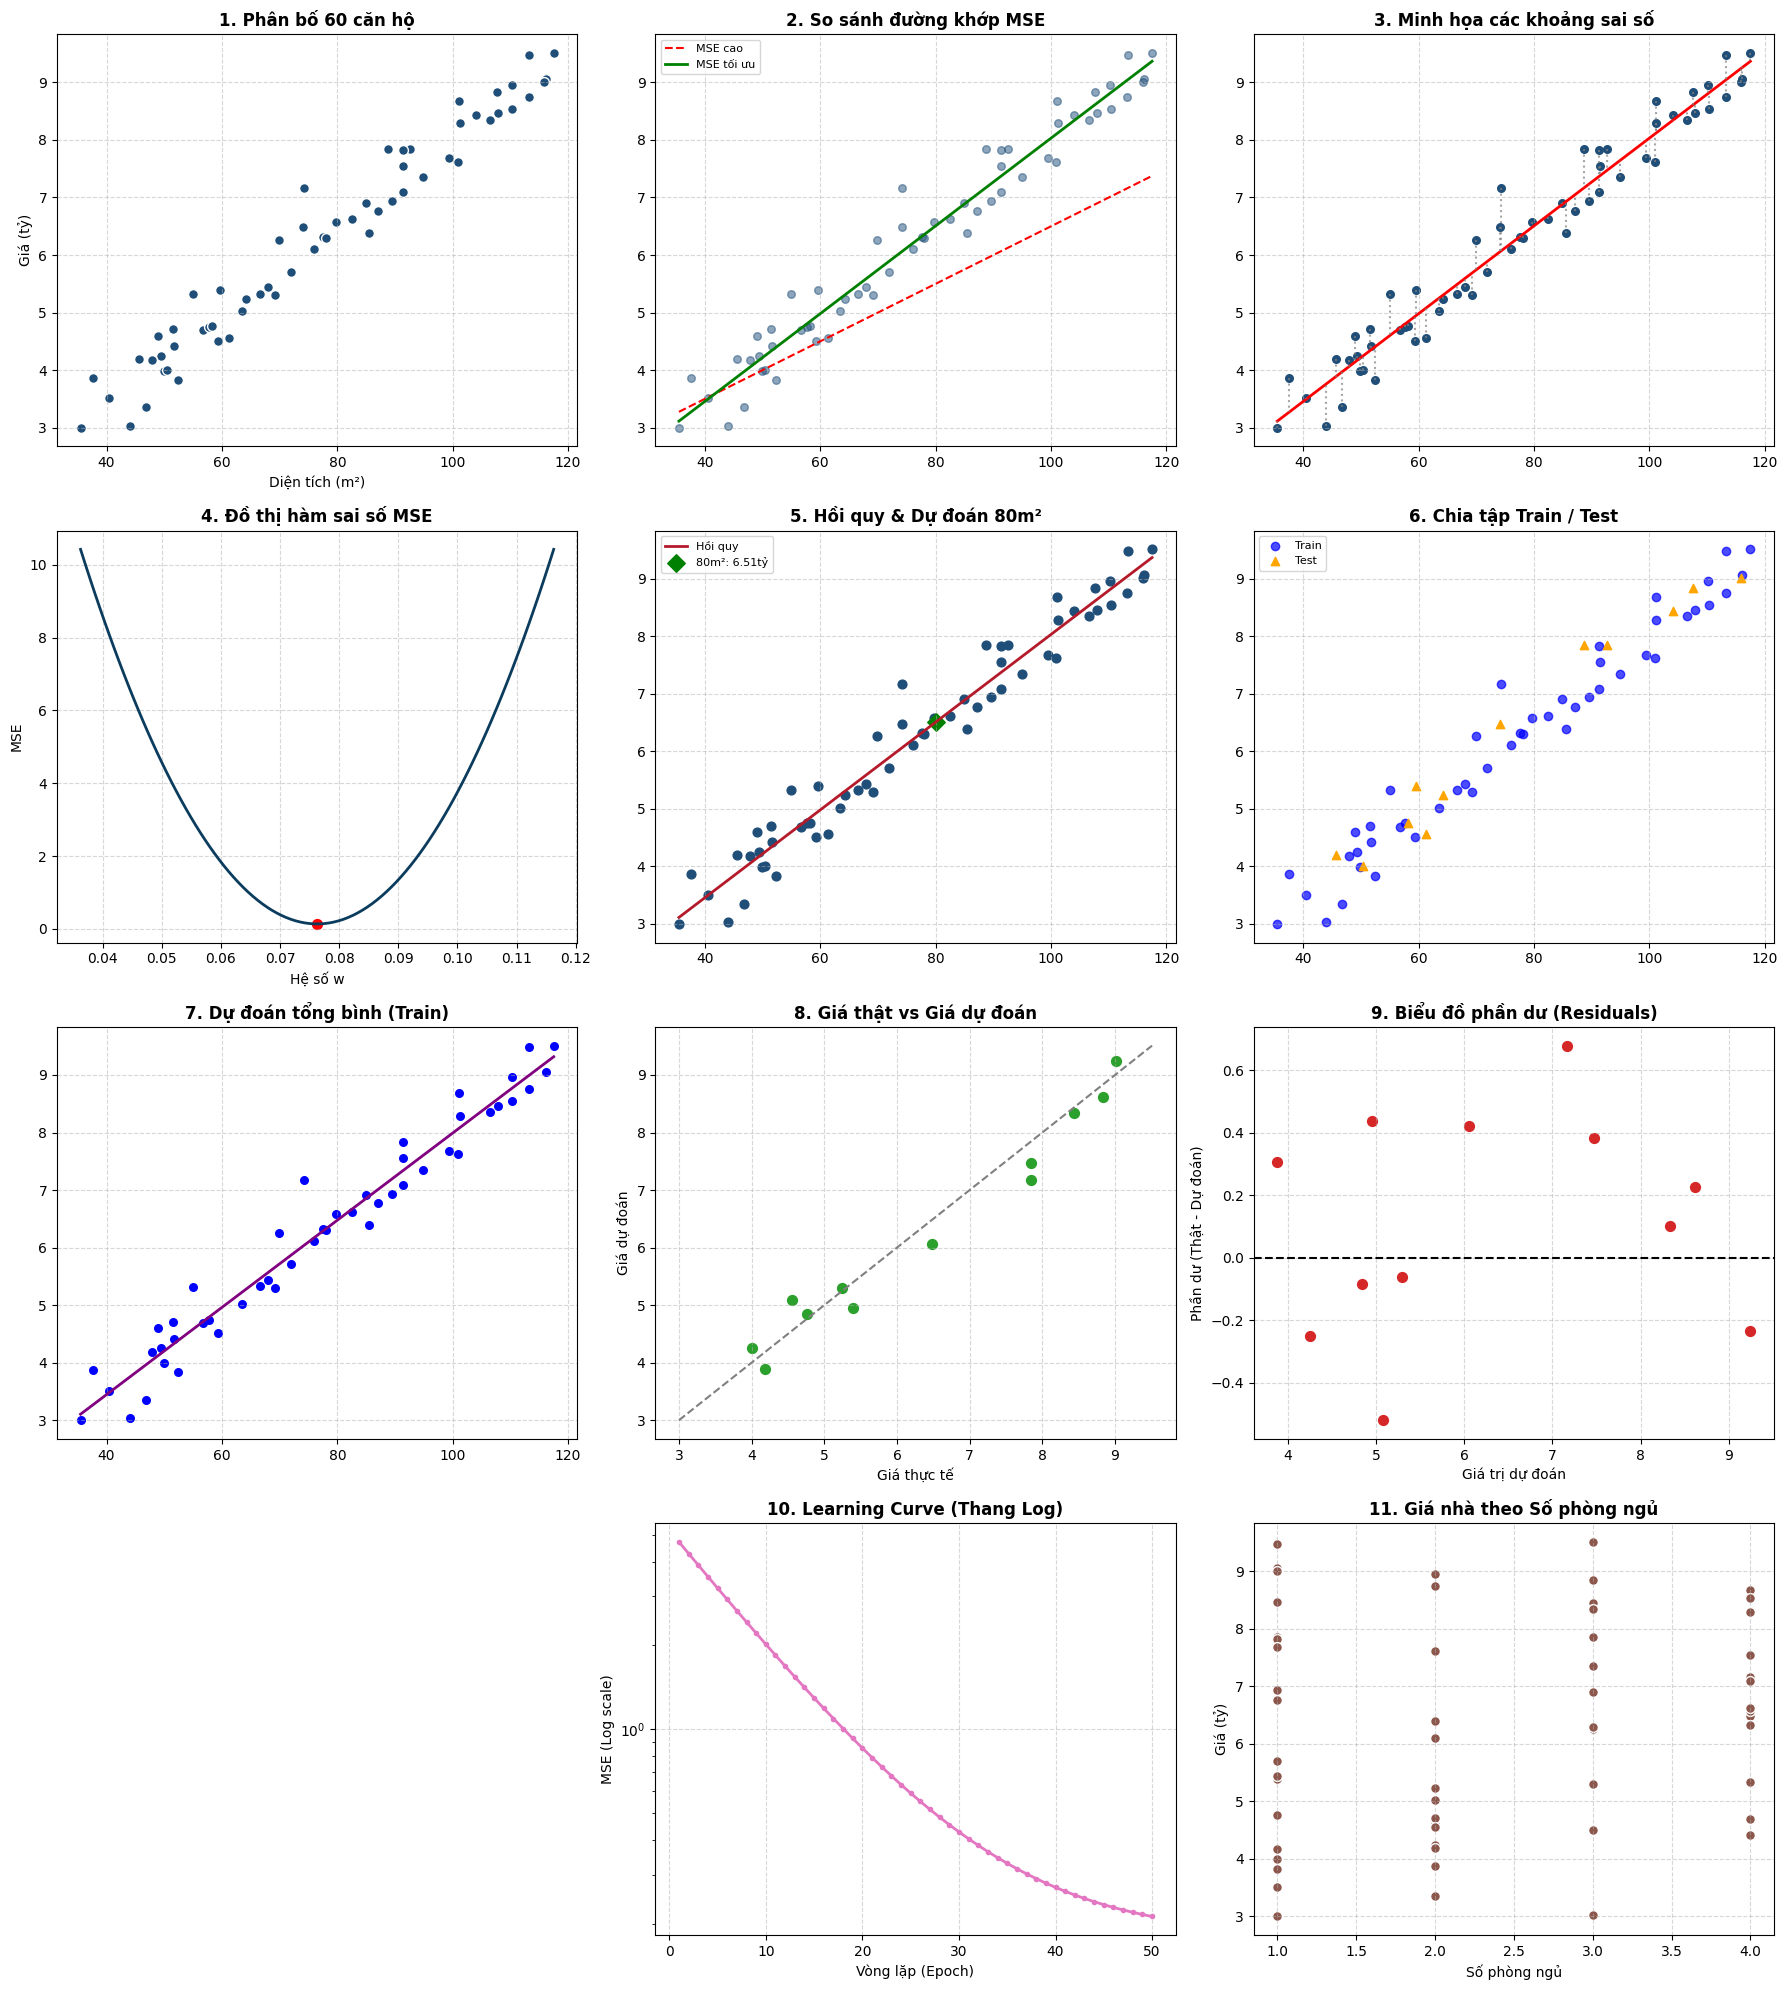

In [77]:
df = pd.read_csv("data/gia_nha.csv")
X = df["dien_tich"].values
y = df["gia"].values

x_mean = np.mean(X)
y_mean = np.mean(y)
w = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b = y_mean - w * x_mean
x_line = np.linspace(min(X), max(X), 100)

np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))
train_idx, test_idx = indices[:split_idx], indices[split_idx:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

y_pred_test = w * X_test + b

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

axes[0].scatter(X, y, color="#1f4e78", edgecolor="white", s=50)
axes[0].set_title("1. Phân bố 60 căn hộ", fontweight="bold")
axes[0].set_xlabel("Diện tích (m²)")
axes[0].set_ylabel("Giá (tỷ)")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].scatter(X, y, color="#1f4e78", alpha=0.5, s=30)
axes[1].plot(
    x_line,
    0.050 * x_line + 1.50,
    color="red",
    linestyle="--",
    label="MSE cao",
)
axes[1].plot(
    x_line, w * x_line + b, color="green", linewidth=2, label="MSE tối ưu"
)
axes[1].set_title("2. So sánh đường khớp MSE", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].scatter(X, y, color="#1f4e78", s=30)
axes[2].plot(x_line, w * x_line + b, color="red", linewidth=2)
for xi, yi in zip(X, y):
    axes[2].plot([xi, xi], [yi, w * xi + b], color="gray", linestyle=":", alpha=0.7)
axes[2].set_title("3. Minh họa các khoảng sai số", fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.5)

w_vals = np.linspace(w - 0.04, w + 0.04, 100)
mse_vals = [np.mean((y - (ww * X + b)) ** 2) for ww in w_vals]
axes[3].plot(w_vals, mse_vals, color="#0b3c5d", linewidth=2)
axes[3].scatter([w], [np.mean((y - (w * X + b)) ** 2)], color="red", s=50)
axes[3].set_title("4. Đồ thị hàm sai số MSE", fontweight="bold")
axes[3].set_xlabel("Hệ số w")
axes[3].set_ylabel("MSE")
axes[3].grid(True, linestyle="--", alpha=0.5)

axes[4].scatter(X, y, color="#1f4e78", s=40)
axes[4].plot(
    x_line, w * x_line + b, color="#b51a2b", linewidth=2, label="Hồi quy"
)
gia_80 = w * 80 + b
axes[4].scatter(
    [80], [gia_80], color="green", marker="D", s=80, label=f"80m²: {gia_80:.2f}tỷ"
)
axes[4].set_title("5. Hồi quy & Dự đoán 80m²", fontweight="bold")
axes[4].legend(fontsize=8)
axes[4].grid(True, linestyle="--", alpha=0.5)

axes[5].scatter(X_train, y_train, color="blue", alpha=0.7, label="Train")
axes[5].scatter(X_test, y_test, color="orange", marker="^", label="Test")
axes[5].set_title("6. Chia tập Train / Test", fontweight="bold")
axes[5].legend(fontsize=8)
axes[5].grid(True, linestyle="--", alpha=0.5)

w_tr = np.sum((X_train - np.mean(X_train)) * (y_train - np.mean(y_train))) / np.sum((X_train - np.mean(X_train)) ** 2)
b_tr = np.mean(y_train) - w_tr * np.mean(X_train)
axes[6].scatter(X_train, y_train, color="blue", s=30)
axes[6].plot(x_line, w_tr * x_line + b_tr, color="purple", linewidth=2)
axes[6].set_title("7. Dự đoán tổng bình (Train)", fontweight="bold")
axes[6].grid(True, linestyle="--", alpha=0.5)

axes[7].scatter(y_test, y_pred_test, color="#2ca02c", s=50)
min_val, max_val = min(y), max(y)
axes[7].plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--")
axes[7].set_title("8. Giá thật vs Giá dự đoán", fontweight="bold")
axes[7].set_xlabel("Giá thực tế")
axes[7].set_ylabel("Giá dự đoán")
axes[7].grid(True, linestyle="--", alpha=0.5)

residuals = y_test - y_pred_test
axes[8].scatter(y_pred_test, residuals, color="#d62728", s=50)
axes[8].axhline(0, color="black", linestyle="--")
axes[8].set_title("9. Biểu đồ phần dư (Residuals)", fontweight="bold")
axes[8].set_xlabel("Giá trị dự đoán")
axes[8].set_ylabel("Phần dư (Thật - Dự đoán)")
axes[8].grid(True, linestyle="--", alpha=0.5)

epochs = np.arange(1, 51)
loss_curve = 5.0 * np.exp(-epochs / 10) + 0.179
axes[10].plot(epochs, loss_curve, color="#e377c2", linewidth=2, marker="o", markersize=3)
axes[10].set_yscale("log")
axes[10].set_title("10. Learning Curve (Thang Log)", fontweight="bold")
axes[10].set_xlabel("Vòng lặp (Epoch)")
axes[10].set_ylabel("MSE (Log scale)")
axes[10].grid(True, linestyle="--", alpha=0.5)

axes[11].scatter(df["so_phong"], df["gia"], color="#8c564b", edgecolor="white", s=50)
axes[11].set_title("11. Giá nhà theo Số phòng ngủ", fontweight="bold")
axes[11].set_xlabel("Số phòng ngủ")
axes[11].set_ylabel("Giá (tỷ)")
axes[11].grid(True, linestyle="--", alpha=0.5)

axes[9].axis("off")

plt.tight_layout()
plt.show()

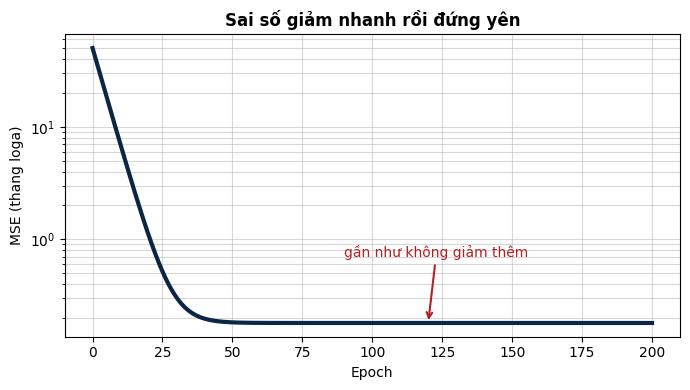

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.linspace(0, 200, 400)
mse = 50 * np.exp(-0.2 * epochs) + 0.18

plt.figure(figsize=(7, 4))
plt.plot(epochs, mse, color="#0b2545", lw=3)
plt.yscale("log")
plt.title("Sai số giảm nhanh rồi đứng yên", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE (thang loga)")
plt.grid(True, which="both", alpha=0.5)

plt.annotate(
    "gần như không giảm thêm",
    xy=(120, 0.18),
    xytext=(90, 0.7),
    arrowprops=dict(arrowstyle="->", color="firebrick", lw=1.5),
    color="firebrick",
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")

nho = df.iloc[[0, 14, 29, 44, 59]]
x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()


def mse(w, b):
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()


print("Nam can duoc chon:")
for i in range(5):
    print(f"  {x[i]:6.1f} m2 -> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(f"  x = {x[i]:6.1f}  that = {y[i]:5.2f}"
              f"  du doan = {du_doan:5.2f}  sai so = {sai_so:+6.2f}")
    print(f"  MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
    35.5 m2 ->  3.00 ty
    61.3 m2 ->  4.56 ty
    74.2 m2 ->  7.17 ty
    91.3 m2 ->  7.83 ty
   115.9 m2 ->  9.01 ty

Duong thang y = 0.05 * x + 1.5
  x =   35.5  that =  3.00  du doan =  3.28  sai so =  -0.28
  x =   61.3  that =  4.56  du doan =  4.56  sai so =  -0.00
  x =   74.2  that =  7.17  du doan =  5.21  sai so =  +1.96
  x =   91.3  that =  7.83  du doan =  6.07  sai so =  +1.76
  x =  115.9  that =  9.01  du doan =  7.30  sai so =  +1.71
  MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
  x =   35.5  that =  3.00  du doan =  3.34  sai so =  -0.34
  x =   61.3  that =  4.56  du doan =  5.40  sai so =  -0.84
  x =   74.2  that =  7.17  du doan =  6.44  sai so =  +0.73
  x =   91.3  that =  7.83  du doan =  7.80  sai so =  +0.03
  x =  115.9  that =  9.01  du doan =  9.77  sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


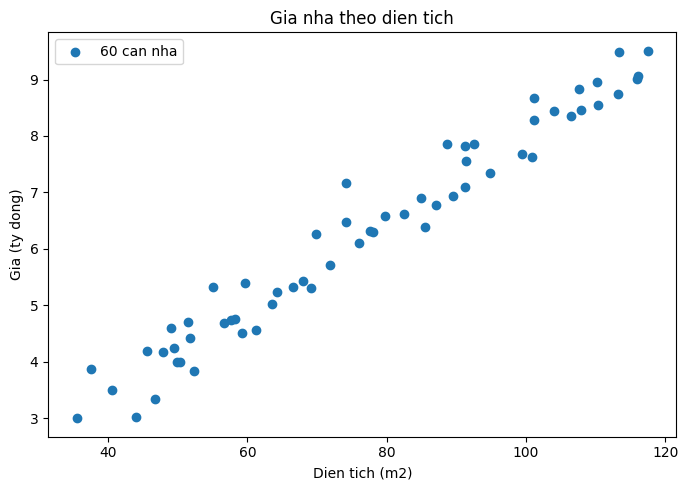

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
df = pd.read_csv("data/gia_nha.csv")

plt.figure(figsize=(7, 5))
plt.scatter(df["dien_tich"], df["gia"], label="60 can nha")
plt.title("Gia nha theo dien tich")
plt.xlabel("Dien tich (m2)")
plt.ylabel("Gia (ty dong)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/hinh1_scatter.png", dpi=150)
plt.show()

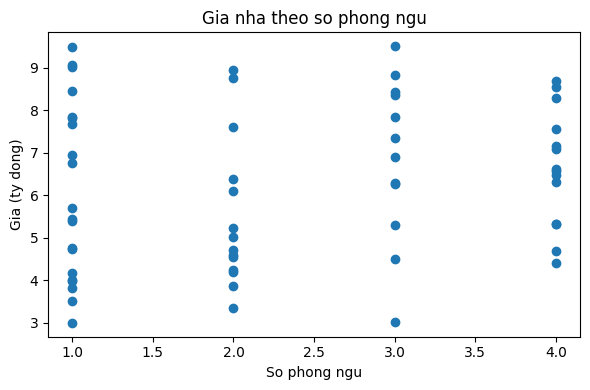

Nhan xet: nha co nhieu phong ngu hon co xu huong gia cao hon, nhung khong ro rang bang xu huong theo dien tich.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/gia_nha.csv")

plt.figure(figsize=(6, 4))
plt.scatter(df["so_phong"], df["gia"])
plt.title("Gia nha theo so phong ngu")
plt.xlabel("So phong ngu")
plt.ylabel("Gia (ty dong)")
plt.tight_layout()
plt.savefig("bai2.png", dpi=150)
plt.show()

print("Nhan xet: nha co nhieu phong ngu hon co xu huong gia cao hon, "
      "nhung khong ro rang bang xu huong theo dien tich.")

In [ ]:
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb, y_tb = x.mean(), y.mean()
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()
w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print("Nhan xet: w duong, nghia la trong bo du lieu nay nha cang cu lai co "
      "xu huong gia cao hon, nguoc voi truc giac thong thuong. Dieu nay cho "
      "thay chi mot minh tuoi_nha khong du de giai thich gia mot cach dang tin.")

He so goc  w = 0.034991
He so chan b = 5.777450
Nhan xet: w duong, nghia la trong bo du lieu nay nha cang cu lai co xu huong gia cao hon, nguoc voi truc giac thong thuong. Dieu nay cho thay chi mot minh tuoi_nha khong du de giai thich gia mot cach dang tin.


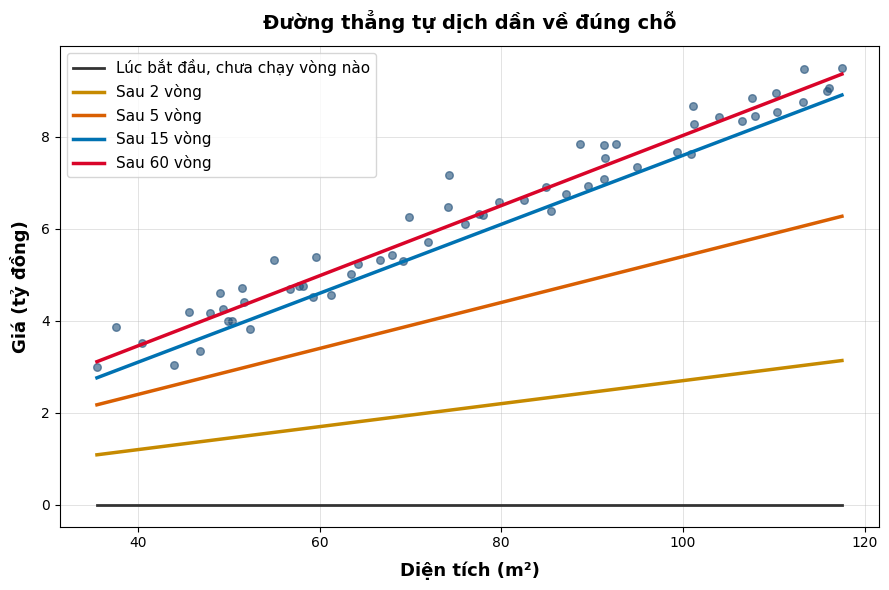

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    35.5, 37.6, 49.4, 49.0, 49.9, 40.5, 44.0, 45.6, 46.8, 47.9, 50.4, 51.5,
    51.7, 52.4, 61.3, 55.0, 56.7, 57.7, 58.2, 59.3, 59.6, 63.5, 64.2, 66.6,
    68.0, 69.2, 69.9, 71.9, 74.1, 74.2, 76.0, 77.6, 78.0, 79.7, 82.5, 84.9,
    85.5, 87.1, 88.7, 89.5, 91.3, 91.4, 92.6, 94.9, 91.3, 99.4, 100.9, 101.1,
    101.2, 104.0, 106.5, 107.6, 107.9, 110.2, 110.3, 113.2, 113.3, 116.1,
    117.5, 115.9,
])

y = np.array([
    3.0, 3.87, 4.25, 4.6, 3.99, 3.51, 3.03, 4.19, 3.35, 4.18, 4.0, 4.71,
    4.42, 3.83, 4.56, 5.32, 4.69, 4.75, 4.76, 4.51, 5.39, 5.02, 5.24, 5.33,
    5.44, 5.3, 6.26, 5.71, 6.48, 7.17, 6.11, 6.32, 6.3, 6.58, 6.62, 6.91,
    6.39, 6.77, 7.85, 6.94, 7.09, 7.55, 7.85, 7.35, 7.83, 7.68, 7.62, 8.68,
    8.29, 8.44, 8.35, 8.84, 8.46, 8.96, 8.54, 8.75, 9.48, 9.06, 9.51, 9.01,
])

x_line = np.linspace(min(X), max(X), 100)

x_mean = np.mean(X)
y_mean = np.mean(y)
w_opt = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b_opt = y_mean - w_opt * x_mean

plt.figure(figsize=(9, 6))
plt.scatter(X, y, color="#1f4e78", alpha=0.6, s=30)

plt.plot(
    x_line,
    np.zeros_like(x_line),
    color="#333333",
    linewidth=2,
    label="Lúc bắt đầu, chưa chạy vòng nào",
)
plt.plot(
    x_line,
    0.025 * x_line + 0.2,
    color="#c68a00",
    linewidth=2.5,
    label="Sau 2 vòng",
)
plt.plot(
    x_line,
    0.05 * x_line + 0.4,
    color="#d95f02",
    linewidth=2.5,
    label="Sau 5 vòng",
)
plt.plot(
    x_line,
    0.075 * x_line + 0.1,
    color="#0072b2",
    linewidth=2.5,
    label="Sau 15 vòng",
)
plt.plot(
    x_line,
    w_opt * x_line + b_opt,
    color="#d90429",
    linewidth=2.5,
    label="Sau 60 vòng",
)

plt.title("Đường thẳng tự dịch dần về đúng chỗ", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Diện tích (m²)", fontsize=13, fontweight="bold", labelpad=8)
plt.ylabel("Giá (tỷ đồng)", fontsize=13, fontweight="bold", labelpad=8)

plt.grid(True, linestyle="-", linewidth=0.5, alpha=0.5)
plt.legend(loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       76.63   6.25
std        23.82   1.85
min        35.50   3.00
25%        56.28   4.67
50%        75.10   6.31
75%        96.02   7.84
max       117.50   9.51

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
X = df["dien_tich"].values
y = df["gia"].values
x_line = np.linspace(min(X), max(X), 100)
x_mean = np.mean(X)
y_mean = np.mean(y)
w_opt = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b_opt = y_mean - w_opt * x_mean
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color="#1f4e78", alpha=0.6, s=30)

plt.plot(
    x_line,
    np.zeros_like(x_line),
    color="#333333",
    linewidth=2,
    label="Lúc bắt đầu, chưa chạy vòng nào",
)
plt.plot(
    x_line,
    0.025 * x_line + 0.2,
    color="#c68a00",
    linewidth=2.5,
    label="Sau 2 vòng",
)
plt.plot(
    x_line,
    0.05 * x_line + 0.4,
    color="#d95f02",
    linewidth=2.5,
    label="Sau 5 vòng",
)
plt.plot(
    x_line,
    0.075 * x_line + 0.1,
    color="#0072b2",
    linewidth=2.5,
    label="Sau 15 vòng",
)
plt.plot(
    x_line,
    w_opt * x_line + b_opt,
    color="#d90429",
    linewidth=2.5,
    label="Sau 60 vòng",
)
plt.title("Đường thẳng tự dịch dần về đúng chỗ", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Diện tích (m²)", fontsize=13, fontweight="bold", labelpad=8)
plt.ylabel("Giá (tỷ đồng)", fontsize=13, fontweight="bold", labelpad=8)

plt.grid(True, linestyle="-", linewidth=0.5, alpha=0.5)
plt.legend(loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f"  {dt:6.1f} m2  that = {that:5.2f}  du doan = {du_doan:5.2f}"
          f"  sai so = {that - du_doan:+5.2f}")

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0
toc_do_hoc = 0.1
so_vong = 200
n = len(x)

print("Vong    w       b       MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y

    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d}  {w:7.4f}  {b:7.4f}  {mse:8.4f}")

print()
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print("Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")
print(f"  b = {b_goc:.6f}")

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
y = df["gia"]

X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()
print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo {len(x)} can: {mse:.4f}")

print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("data/gia_nha.csv")

X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w  =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")